# Bifurcation Diagrams

We again consider the logistic map, $$x_{n+1} = ax_n(1-x_n).$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def logistic_map(x, a=1):
    return a*x*(1-x)

def logistic_series(x0, n, a=1):
    xs = [x0]
    for _ in range(n):
        xi = logistic_map(xs[-1], a)
        xs.append(xi)
    return xs

def tail_values(x0, n_total, n_skip, a):
    xs = logistic_series(x0, n_total, a=a)
    return xs[n_skip:]

def long_run_values(a_values, x0, n_total=300, n_skip=200):
    xs_all = []
    as_all = []
    for a in a_values:
        tail = tail_values(x0, n_total, n_skip, a)
        xs_all.extend(tail)
        as_all.extend([a] * len(tail))
    return as_all, xs_all

### Bifurcation over $a$

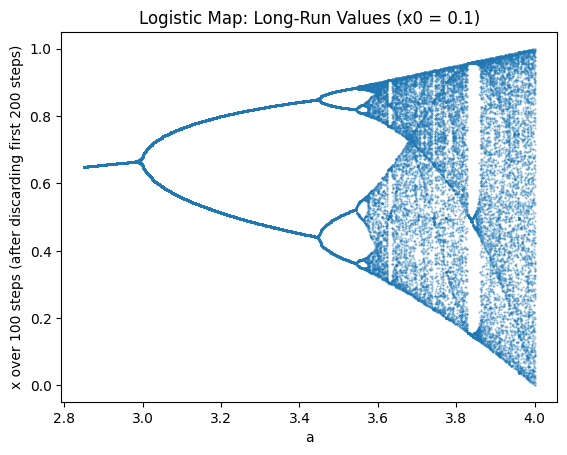

In [9]:
avals = np.linspace(2.85, 4.0, 500)
as_all, xs_all = long_run_values(avals, x0=0.1)
plt.plot(as_all, xs_all, '.', markersize=1, alpha=0.5)
plt.xlabel('a')
plt.ylabel('x over 100 steps (after discarding first 200 steps)')
plt.title('Logistic Map: Long-Run Values (x0 = 0.1)')
plt.show()

Now we zoom in over $3.0 < a < 3.57$ to examine the period doubling regime more closely and estimate the Feigenbaum number.

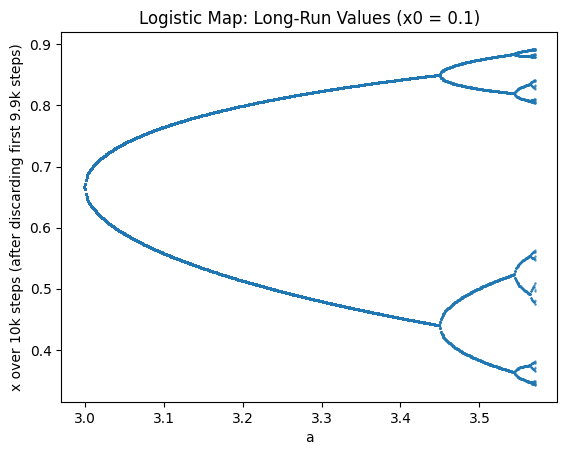

In [47]:
# note: we let the map run for really long (i.e., 10k steps) to get stable cycle estimates
avals = np.linspace(2.999, 3.57, 500)
as_all, xs_all = long_run_values(avals, x0=0.1, n_total=10000, n_skip=9900)
plt.plot(as_all, xs_all, '.', markersize=1, alpha=0.5)
plt.xlabel('a')
plt.ylabel('x over 10k steps (after discarding first 9.9k steps)')
plt.title('Logistic Map: Long-Run Values (x0 = 0.1)')
plt.show()

The Feigenbaum number is the spacing between successive bifurcations, and is defined as $$\delta = \lim_{n\to\infty}\frac{a_n - a_{n-1}}{a_{n+1}-a_n} \approx 4.669201\ldots$$

In [87]:
def empirical_feigenbaum(as_all, xs_all, log2ncycle=4, atol=1e-8, init_target=2):
    # find index ranges of a values
    aidxs = [0]
    for i in range(len(as_all) - 1):
        if as_all[i] != as_all[i + 1]:
            aidxs.append(i + 1)
    aidxs.append(len(as_all))

    # find first a_n where period is (approximately) 2^n
    a_ns = []
    target = init_target
    for j in range(len(aidxs) - 1):
        lo, hi = aidxs[j], aidxs[j + 1]
        xs = np.sort(np.array(xs_all[lo:hi], dtype=float))
        if len(xs) == 0:
            continue
        n_unique = 1 + np.count_nonzero(np.diff(xs) > atol)

        # require a near-power-of-two
        if n_unique == target:
            a_ns.append(as_all[lo])
            target *= 2
            if target > target*(2**(log2ncycle-1)):
                break

    # compute feigenbaum number estimates over 2^log2n-cycles
    deltas = []
    for i in range(1, len(a_ns) - 1):
        num = a_ns[i] - a_ns[i - 1]
        den = a_ns[i + 1] - a_ns[i]
        if den != 0:
            deltas.append(num / den)

    return np.array(a_ns), np.array(deltas), aidxs

In [ ]:
a_ns, deltas, aidxs = empirical_feigenbaum(as_all, xs_all)
print('a_ns:', a_ns)
print('deltas:', deltas)
if len(deltas):
    print('Empirical Feigenbaum estimate:', deltas[-1])
else:
    print('No stable estimate found. Increase n_total/n_skip or adjust atol.')

a_ns: [2.999      3.4498497  3.54482565 3.56542285]
deltas: [4.74698795 4.61111111]
Empirical Feigenbaum estimate: 4.611111111111123


### $n$-Cycles

First, we look more closely in the region around $3$-cycles at $a\approx3.82$ and the map's transition back to chaos through period-doubling over increasing $a$.

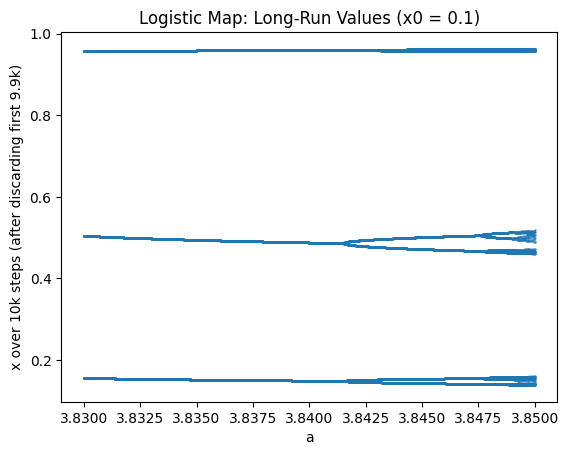

In [88]:
# note: we let the map run for really long (i.e., 10k steps) to get stable cycle estimates
avals = np.linspace(3.83, 3.85, 500)
as_all, xs_all = long_run_values(avals, x0=0.1, n_total=10000, n_skip=9900)
plt.plot(as_all, xs_all, '.', markersize=1, alpha=0.5)
plt.xlabel('a')
plt.ylabel('x over 10k steps (after discarding first 9.9k)')
plt.title('Logistic Map: Long-Run Values (x0 = 0.1)')
plt.show()

In [99]:
a_ns, deltas, aidxs = empirical_feigenbaum(as_all, xs_all, log2ncycle=5, atol=1e-7, init_target=3)
print('a_ns:', a_ns)
print('deltas:', deltas)
if len(deltas):
    print('Empirical Feigenbaum estimate:', deltas[-1])
else:
    print('No stable estimate found. Increase n_total/n_skip or adjust atol.')

a_ns: [3.83       3.84150301 3.84763527 3.84903808 3.84935872]
deltas: [1.87581699 4.37142857 4.375     ]
Empirical Feigenbaum estimate: 4.374999999999307


Now, to find the value of $a$ for which there exists a $5$-cycle, we need that $x_i = x_{i+5k}$, for $i, k \in \mathbb{N}_0$. This is a $32^\text{nd}$-order polynomial. Accounting for trivial zeros $x^\star = \{0, 1-\frac{1}{a}\}$, we will be left with a $30^\text{th}$-order polynomial, implying $6$ distinct $5$-cycles (chains of successive roots). To find suitable values of $a$, we need to find one non-trivial root of that polynomial, and then ensure the stability of the chain, requiring $$\Biggm|\prod_{i=1}^{5}a(1-2x_i)\Biggm|<1.$$ Additionally, it will require all roots to be real. But here, note that such cases are usually have zero measure, and so randomly sampling and nudging will mostly not work. Instead we could build a "superstable" $n$-cycle, wherein one of the derivatives is zero, which would be if $x^\star = \frac{1}{2}$. Therefore, taking that as a root and searching for $a$'s that preserve the stability requirement is much more efficient, and guaranteed to work in finding such $n$-cycles.

In [ ]:
import sympy as sp

a = sp.symbols('a')
x = sp.Rational(1, 2)

# compute f^5(1/2; a)
for _ in range(5):
    x = a*x*(1-x)

# solve f^5(1/2; a) = 1/2
poly = sp.Poly(sp.expand(x-sp.Rational(1, 2)), a)
roots = poly.nroots()

# keep only real roots in [3, 4)
real_roots = sorted(
    r.as_real_imag()[0]
    for r in roots
    if abs(sp.N(r.as_real_imag()[1])) < 1e-12 and 3 <= sp.N(r.as_real_imag()[0]) < 4
)

print(real_roots)

[3.73891491297069, 3.90570646983129, 3.99026704697370]


Using the any of the printed roots as a solution, we should see a stable $5$-cycle.

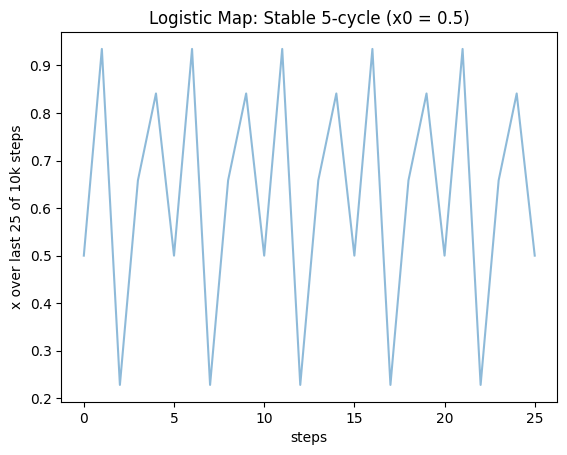

In [104]:
as_all, xs_all = long_run_values([3.73891491297069], 0.5, n_total=10000, n_skip=9975)
plt.plot(xs_all, '-', markersize=1, alpha=0.5)
plt.xlabel('steps')
plt.ylabel('x over last 25 of 10k steps')
plt.title('Logistic Map: Stable 5-cycle (x0 = 0.5)')
plt.show()